# Import Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [5]:
df = pd.read_csv("IMDB Dataset.csv", encoding='utf-8', engine='python', on_bad_lines='skip')
df = df.sample(n=min(5000, len(df)), random_state=42)
df = df.reset_index(drop=True)
df.head()

,review,sentiment
0,I've seen several stage and film adaptations o...,negative
1,Contains spoilers. <br /><br />The British dir...,negative
2,This movie is likely the worst movie I've ever...,negative
3,Every high praise word fell way short before t...,positive
4,"""Back of Beyond"" takes place at a dive diner/g...",negative


# Basic Info

In [6]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     5000 non-null   object
 1   sentiment  5000 non-null   object
dtypes: object(2)
memory usage: 78.3+ KB


In [7]:
df.isnull().sum()

,0
review,0
sentiment,0


# Class Distribution

sentiment
negative    2508
positive    2492
Name: count, dtype: int64


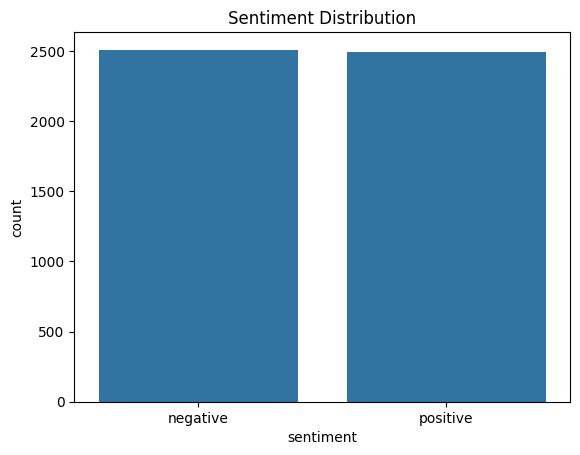

In [8]:
print(df['sentiment'].value_counts())
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

# Convert Labels to Numeric

In [9]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})
df.head()

,review,sentiment
0,I've seen several stage and film adaptations o...,0
1,Contains spoilers. <br /><br />The British dir...,0
2,This movie is likely the worst movie I've ever...,0
3,Every high praise word fell way short before t...,1
4,"""Back of Beyond"" takes place at a dive diner/g...",0


# Downloading Required Data

In [10]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


# Creating Preprocessing Function

In [11]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]

    return " ".join(tokens)

In [12]:
df['cleaned_review'] = df['review'].apply(preprocess_text)

In [13]:
df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,I've seen several stage and film adaptations o...,seen sever stage film adapt alic wonderland on...
1,Contains spoilers. <br /><br />The British dir...,contain spoiler british director j lee thompso...
2,This movie is likely the worst movie I've ever...,movi like worst movi ever seen life surpass pr...
3,Every high praise word fell way short before t...,everi high prais word fell way short height mo...
4,"""Back of Beyond"" takes place at a dive diner/g...",back beyond take place dive diner ga station m...


# Train-Test Split

In [18]:
X = df['cleaned_review']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)
X_train_bow.shape

(4000, 5000)

In [20]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
X_train_tfidf.shape

(4000, 5000)

# Logistic Regression
On BoW

In [22]:
lr_bow = LogisticRegression()
lr_bow.fit(X_train_bow, y_train)
y_pred_lr_bow = lr_bow.predict(X_test_bow)

On TF-IDF

In [23]:
lr_tfidf = LogisticRegression()
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

# Naive Bayes
On BoW

In [24]:
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_nb_bow = nb_bow.predict(X_test_bow)

On TF-IDF

In [25]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

# Decision Tree
On BoW

In [26]:
dt_bow = DecisionTreeClassifier()
dt_bow.fit(X_train_bow, y_train)
y_pred_dt_bow = dt_bow.predict(X_test_bow)

On TF-IDF

In [27]:
dt_tfidf = DecisionTreeClassifier()
dt_tfidf.fit(X_train_tfidf, y_train)
y_pred_dt_tfidf = dt_tfidf.predict(X_test_tfidf)

# Model Evaluation

In [29]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    return acc, prec, rec, f1

# Evaluate All Models
### Logistic Regression

In [30]:
lr_bow_metrics = evaluate_model(y_test, y_pred_lr_bow, "Logistic Regression (BoW)")
lr_tfidf_metrics = evaluate_model(y_test, y_pred_lr_tfidf, "Logistic Regression (TF-IDF)")


--- Logistic Regression (BoW) ---
Accuracy  : 0.8560
Precision : 0.8455
Recall    : 0.8661
F1 Score  : 0.8557

--- Logistic Regression (TF-IDF) ---
Accuracy  : 0.8760
Precision : 0.8555
Recall    : 0.9006
F1 Score  : 0.8775


### Naive Bayes

In [31]:
nb_bow_metrics = evaluate_model(y_test, y_pred_nb_bow, "Naive Bayes (BoW)")
nb_tfidf_metrics = evaluate_model(y_test, y_pred_nb_tfidf, "Naive Bayes (TF-IDF)")


--- Naive Bayes (BoW) ---
Accuracy  : 0.8430
Precision : 0.8429
Recall    : 0.8377
F1 Score  : 0.8403

--- Naive Bayes (TF-IDF) ---
Accuracy  : 0.8440
Precision : 0.8432
Recall    : 0.8398
F1 Score  : 0.8415


### Decision Tree

In [32]:
dt_bow_metrics = evaluate_model(y_test, y_pred_dt_bow, "Decision Tree (BoW)")
dt_tfidf_metrics = evaluate_model(y_test, y_pred_dt_tfidf, "Decision Tree (TF-IDF)")


--- Decision Tree (BoW) ---
Accuracy  : 0.7020
Precision : 0.7027
Recall    : 0.6856
F1 Score  : 0.6940

--- Decision Tree (TF-IDF) ---
Accuracy  : 0.6980
Precision : 0.6937
Recall    : 0.6937
F1 Score  : 0.6937


# Create Comparison Table

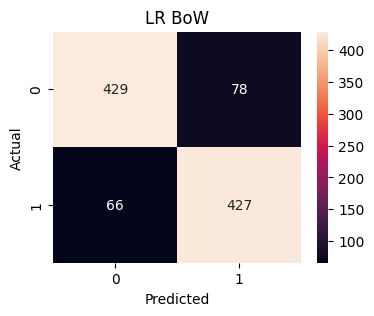

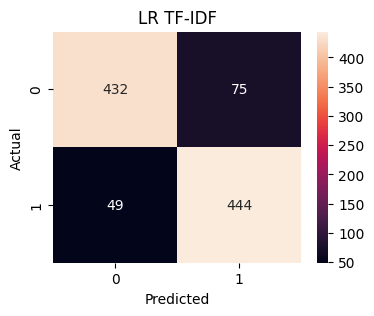

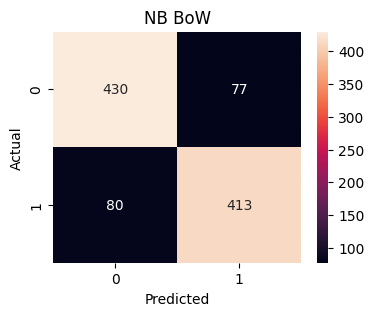

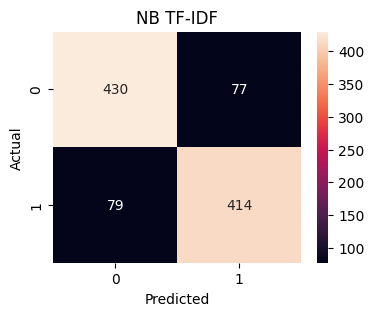

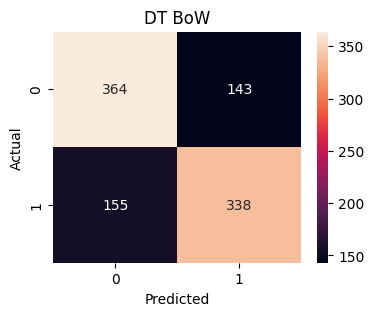

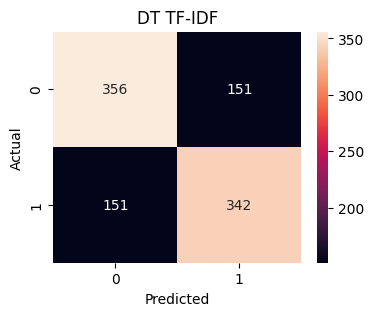

In [35]:
models = {
    "LR BoW": y_pred_lr_bow,
    "LR TF-IDF": y_pred_lr_tfidf,
    "NB BoW": y_pred_nb_bow,
    "NB TF-IDF": y_pred_nb_tfidf,
    "DT BoW": y_pred_dt_bow,
    "DT TF-IDF": y_pred_dt_tfidf
}

for name, preds in models.items():
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Summary of Findings

This project implemented a complete Sentiment Analysis pipeline using NLP preprocessing, feature engineering, and multiple machine learning models.

Initially, raw text data was cleaned using several preprocessing techniques such as lowercasing, removal of punctuation, stopwords removal, tokenization, and stemming. This helped in reducing noise and improving the quality of textual data.

For feature engineering, two approaches were used: Bag of Words (BoW) and TF-IDF. TF-IDF performed better than BoW in most cases as it assigns higher importance to meaningful and less frequent words, while reducing the impact of commonly occurring words.

Three machine learning models were trained and evaluated: Logistic Regression, Naive Bayes, and Decision Tree. Among these, Logistic Regression achieved the best performance, especially when combined with TF-IDF features. It provided a good balance between precision and recall, resulting in the highest F1 score.

Naive Bayes performed well and was computationally efficient, but slightly less accurate compared to Logistic Regression. Decision Tree showed comparatively lower performance and signs of overfitting, especially on high-dimensional sparse data like text.

## Final Result
Confusion matrix analysis showed that Logistic Regression correctly classified most of the positive and negative samples, with fewer false predictions compared to other models.

Overall, TF-IDF with Logistic Regression proved to be the most effective combination for sentiment classification in this project.


### Dataset Source:
https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews